In [34]:
import os
import pandas as pd
from pathlib import Path
from MDToolkit.IO.read_file import read_lammps_log_file

In [35]:
file_dir = Path("/media/jrjoseph/Elements/projects/smaller_kcl_mos2_ls6/v1/")

files = list(file_dir.glob("relaxation_job_output.o*"))

dfs = [read_lammps_log_file(file) for file in files]

df = (pd.concat(dfs, ignore_index=True).sort_values("Step").reset_index(drop=True))

In [36]:
#####################################################
# Plotting Functions
#####################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_lammps_thermo(
    df: pd.DataFrame,
    timestep_col: str = "Step",
    rolling_window: int = 100,
    show_std: bool = True,
    std_scale: float = 1.0,
    figsize=(8, 4),
    marker_size: float = 3,
    point_alpha: float = 0.05,
    line_width: float = 2.5,
):
    """
    Plot each LAMMPS thermo quantity in a separate figure.

    Parameters
    ----------
    df : pandas.DataFrame
        Thermo dataframe.
    timestep_col : str
        Column containing timestep values.
    rolling_window : int
        Rolling average window in number of samples.
    show_std : bool
        Plot rolling standard deviation band.
    std_scale : float
        Multiplier for standard deviation band.
    figsize : tuple
        Figure size.
    marker_size : float
        Raw point size.
    point_alpha : float
        Raw point transparency.
    line_width : float
        Rolling average line width.

    Returns
    -------
    figures : dict
        Dictionary of matplotlib figures keyed by quantity.
    """

    units = {
        "Step": "fs",
        "Temp": "K",
        "Press": "atm",
        "Density": "g/cm³",
        "PotEng": "kcal/mol",
        "KinEng": "kcal/mol",
        "TotEng": "kcal/mol",
        "E_pair": "kcal/mol",
        "E_mol": "kcal/mol",
        "Volume": "Å³",
        "Lx": "Å",
        "Ly": "Å",
        "Lz": "Å",
    }

    x = df[timestep_col].to_numpy()

    figures = {}

    for col in df.columns:

        if col == timestep_col:
            continue

        y = df[col].to_numpy(dtype=float)

        series = pd.Series(y)

        rolling_mean = (
            series
            .rolling(
                window=rolling_window,
                center=True,
                min_periods=max(1, rolling_window // 2),
            )
            .mean()
            .to_numpy()
        )

        rolling_std = (
            series
            .rolling(
                window=rolling_window,
                center=True,
                min_periods=max(1, rolling_window // 2),
            )
            .std()
            .to_numpy()
        )

        fig, ax = plt.subplots(figsize=figsize)

        # Error band first
        if show_std:
            ax.fill_between(
                x,
                rolling_mean - std_scale * rolling_std,
                rolling_mean + std_scale * rolling_std,
                color="0.75",
                alpha=0.45,
                linewidth=0,
                zorder=0,
                label=f"±{std_scale:g}σ",
            )

        # Raw points
        ax.scatter(
            x,
            y,
            s=marker_size,
            color="tab:blue",
            alpha=point_alpha,
            edgecolors="none",
            rasterized=True,
            zorder=1,
            label="Raw data",
        )

        # Rolling average
        ax.plot(
            x,
            rolling_mean,
            color="tab:red",
            linewidth=line_width,
            zorder=2,
            label=f"Rolling mean ({rolling_window})",
        )

        # ------------------------------------------
        # Tight y-axis scaling
        # Use rolling mean ± std, not raw extrema
        # ------------------------------------------
        if show_std:
            finite = np.isfinite(
                rolling_mean - std_scale * rolling_std
            )

            lower = np.nanmin(
                (rolling_mean - std_scale * rolling_std)[finite]
            )

            upper = np.nanmax(
                (rolling_mean + std_scale * rolling_std)[finite]
            )

        else:
            lower = np.nanpercentile(y, 0.5)
            upper = np.nanpercentile(y, 99.5)

        padding = 0.05 * (upper - lower)

        if padding == 0:
            padding = abs(lower) * 0.05

        ax.set_ylim(
            lower - padding,
            upper + padding
        )

        # Labels
        ylabel = col
        if col in units:
            ylabel += f" ({units[col]})"

        ax.set_ylabel(ylabel)

        xlabel = timestep_col
        if timestep_col in units:
            xlabel += f" ({units[timestep_col]})"

        ax.set_xlabel(xlabel)

        ax.set_title(col)

        ax.grid(True, alpha=0.3)
        ax.legend(frameon=True)

        fig.tight_layout()

        figures[col] = fig

    return figures

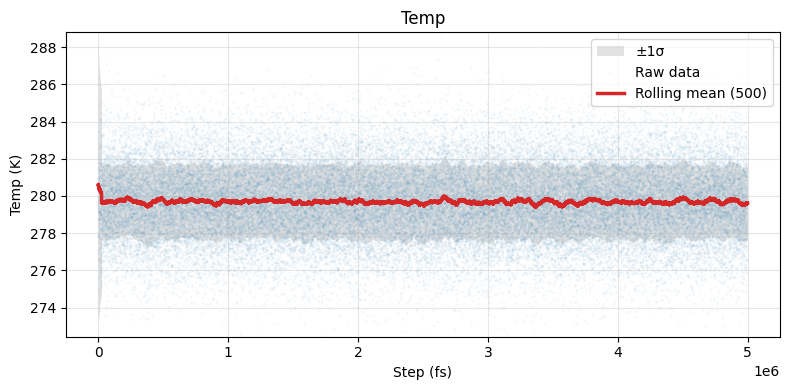

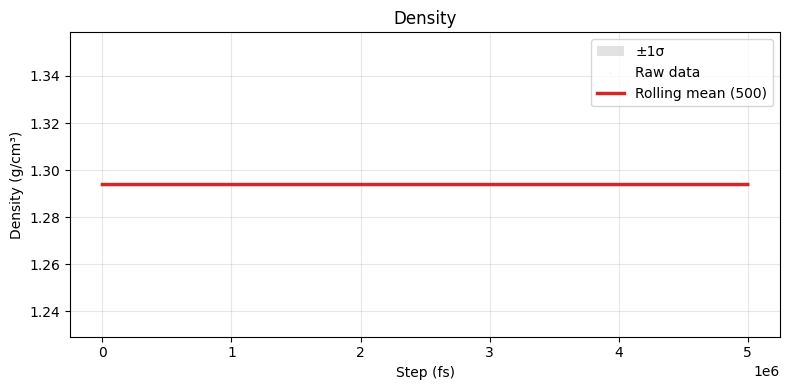

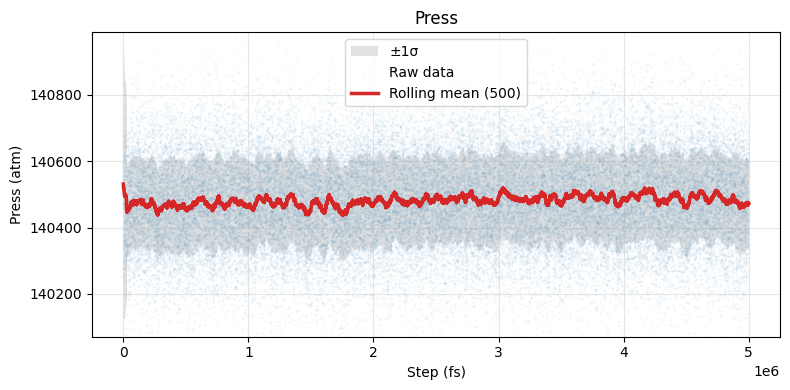

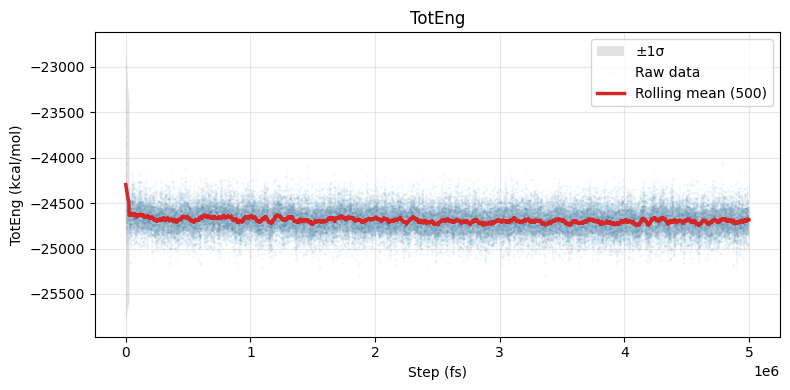

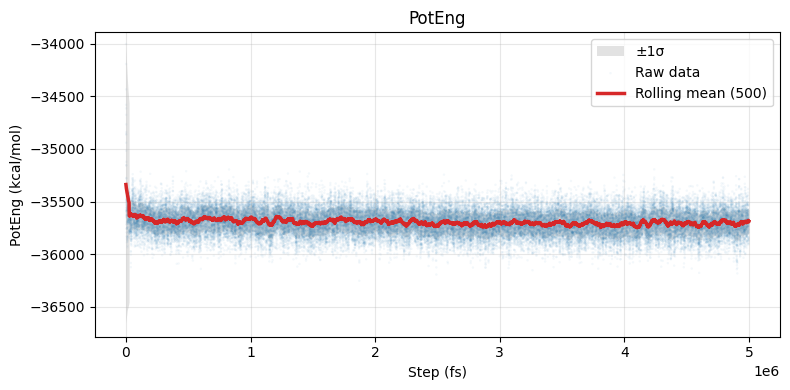

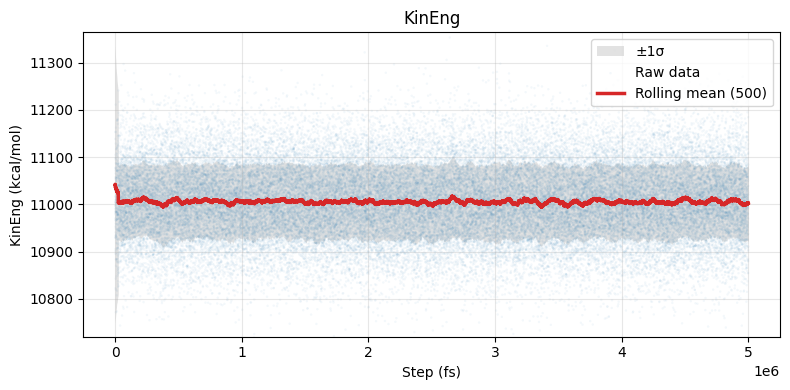

In [37]:
figures = plot_lammps_thermo(
    df,
    rolling_window=500
)

plt.show()